In [ ]:
import pandas as pd
import numpy as np

features = pd.read_csv("merged_output.csv")
ev = pd.read_csv("ev2025.csv")

features.head()

,region_country,year,code,Greenhouse gas emissions per capita,population,electricity_generation,Urban_pct
0,Africa,2000,AFR,15.413796,47243054,210.860004,99.656419
1,Africa,2001,AFR,15.306290,47651426,210.289996,100.218733
2,Africa,2002,AFR,14.794578,48105292,220.810002,100.767205
3,Africa,2003,AFR,15.477100,48587407,234.470006,101.377367
4,Africa,2004,AFR,16.693630,49079595,244.840001,102.021515


In [ ]:
ev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,agg_group,is_projection
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,World,True
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,World,True
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Country,True
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Country,True
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,World,True


In [ ]:
# Generate target: EV sales
ev_sales = (
    ev[
        (ev["category"] == "Historical") &
        (ev["parameter"] == "EV sales") &
        (ev["mode"] == "Cars") &
        (ev["powertrain"].isin(["BEV", "PHEV"])) &
        (ev["year"].between(2010, 2024))
    ]
    .groupby(["region_country", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "ev_sales"})
)

ev_sales.head()

,region_country,year,ev_sales
0,Africa,2013,34.0
1,Africa,2014,15.0
2,Africa,2015,240.0
3,Africa,2016,380.0
4,Africa,2017,202.0


In [ ]:
# Merge target with features
df = features.merge(ev_sales, on=["region_country", "year"], how="inner")

df["ev_sales_log"] = np.log1p(df["ev_sales"])
df["population_log"] = np.log1p(df["population"])
df["electricity_generation_log"] = np.log1p(df["electricity_generation"])
df["electricity_per_capita"] = df["electricity_generation"] / df["population"]

df = df.sort_values(["region_country", "year"])
df.head()

,region_country,year,code,Greenhouse gas emissions per capita,population,electricity_generation,Urban_pct,ev_sales,ev_sales_log,population_log,electricity_generation_log,electricity_per_capita
0,Africa,2013,AFR,15.174379,54780897,256.389997,105.867472,34.0,3.555348,17.818852,5.550592,0.000005
1,Africa,2014,AFR,15.808058,55699503,255.220004,106.073858,15.0,2.772589,17.835482,5.546036,0.000005
2,Africa,2015,AFR,15.410494,56830783,250.510003,106.304439,240.0,5.484797,17.855589,5.527483,0.000004
3,Africa,2016,AFR,15.702925,57369386,253.309998,106.556661,380.0,5.942799,17.865021,5.538554,0.000004
4,Africa,2017,AFR,15.465017,57747601,255.649999,106.827972,202.0,5.313206,17.871592,5.547713,0.000004


In [ ]:
df["region_country"].unique()

array(['Africa', 'Asia Pacific', 'Australia', 'Austria', 'Belgium',
       'Brazil', 'Bulgaria', 'Canada', 'Central and South America',
       'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus',
       'Czech Republic', 'Denmark', 'Estonia', 'Europe', 'Finland',
       'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea',
       'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Mexico',
       'Middle East and Caspian', 'Netherlands', 'New Zealand',
       'North America', 'Norway', 'Poland', 'Portugal', 'Romania',
       'Russia', 'Seychelles', 'Slovakia', 'Slovenia', 'South Africa',
       'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Turkiye', 'USA',
       'United Kingdom', 'Uzbekistan', 'Viet Nam', 'World'], dtype=object)

In [ ]:
country_ev_sales = ev[
    (ev["category"] == "Historical") &
    (ev["agg_group"] == "Country") &
    (ev["parameter"] == "EV sales") &
    (ev["mode"] == "Cars") &
    (ev["powertrain"].isin(["BEV", "PHEV"])) &
    (ev["year"].between(2016, 2024))
].groupby(["region_country", "year"], as_index=False)["value"].sum()

country_ev_sales = country_ev_sales.rename(columns={"value": "ev_sales"})

top_countries = (
    country_ev_sales
    .sort_values(["year", "ev_sales"], ascending=[True, False])
    .groupby("year")
    .head(5)
)

top_countries

,region_country,year,ev_sales
63,China,2016,339000.0
439,USA,2016,160000.0
305,Norway,2016,45000.0
287,Netherlands,2016,43000.0
448,United Kingdom,2016,39000.0
64,China,2017,580000.0
440,USA,2017,194000.0
306,Norway,2017,62000.0
148,Germany,2017,54000.0
228,Japan,2017,54000.0


This output confirms that China ranked first among countries in EV car sales every year from 2016 to 2024. The gap between China and the second-ranked country is large, especially after 2021, suggesting that China’s EV adoption scale is structurally different from other markets.

In [ ]:
# Run model on country only, filter region out
region_names = [
    "World", "Africa", "Asia Pacific", "Europe", "EU27",
    "Central and South America", "Middle East and Caspian", "North America"
]

country_df = df[~df["region_country"].isin(region_names)].copy()

In [ ]:
# First, try linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model_df = country_df.dropna(subset=[
    "ev_sales_log",
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita",
    "electricity_per_capita"
])

features_cols = [
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita",
    "electricity_per_capita"
]

train = model_df[model_df["year"] <= 2021]
test = model_df[model_df["year"] >= 2022]

X_train = train[features_cols]
y_train = train["ev_sales_log"]

X_test = test[features_cols]
y_test = test["ev_sales_log"]

reg = LinearRegression()
reg.fit(X_train, y_train)

pred = reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

pd.DataFrame({
    "feature": features_cols,
    "coefficient": reg.coef_
}).sort_values("coefficient", ascending=False)

MAE: 3.1771401630672167
R2: -1.8315642927400142


,feature,coefficient
2,electricity_generation_log,2.946366
0,Urban_pct,0.023909
3,Greenhouse gas emissions per capita,-0.129248
1,population_log,-2.153585
4,electricity_per_capita,-66151.778228


The linear regression coefficient for Urban_pct is positive, suggesting that higher urbanization is associated with higher EV sales. However, the negative test R2 indicates weak out-of-sample predictive performance. Therefore, this model should be interpreted as exploratory regression rather than a reliable forecasting model.

In [ ]:
import statsmodels.api as sm

model_df = country_df.dropna(subset=[
    "ev_sales_log",
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita"
])

X = model_df[
    [
        "Urban_pct",
        "population_log",
        "electricity_generation_log",
        "Greenhouse gas emissions per capita"
    ]
]

X = sm.add_constant(X)
y = model_df["ev_sales_log"]

ols = sm.OLS(y, X).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:           ev_sales_log   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     63.05
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           5.34e-45
Time:                        02:36:46   Log-Likelihood:                -1522.6
No. Observations:                 651   AIC:                             3055.
Df Residuals:                     646   BIC:                             3078.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

The OLS result shows that Urban_pct has a positive and statistically significant association with EV sales log. A one-point increase in urbanization rate is associated with an increase in log EV sales, holding other variables constant. Electricity generation also has a strong positive relationship with EV sales. However, the R-squared is moderate at 0.281, so these variables explain part, but not all, of the variation in EV sales.

The Durbin-Watson statistic is low and the condition number is high, suggesting possible autocorrelation and multicollinearity. The results are useful for interpretation, but not strong causal proof.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def run_granger_log(country, x_col="Urban_pct", y_col="ev_sales_log", maxlag=2):
    temp = (
        country_df[country_df["region_country"] == country]
        .sort_values("year")[[y_col, x_col]]
        .dropna()
    )

    print(country, temp.shape)

    if len(temp) < maxlag + 5:
        print("Not enough observations")
        return

    return grangercausalitytests(temp[[y_col, x_col]], maxlag=maxlag, verbose=True)

run_granger_log("China", maxlag=2)

China (15, 2)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1
ssr based chi2 test:   chi2=1.2990  , p=0.2544  , df=1
likelihood ratio test: chi2=1.2422  , p=0.2650  , df=1
parameter F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2083  , p=0.3479  , df_denom=8, df_num=2
ssr based chi2 test:   chi2=3.9269  , p=0.1404  , df=2
likelihood ratio test: chi2=3.4314  , p=0.1798  , df=2
parameter F test:         F=1.2083  , p=0.3479  , df_denom=8, df_num=2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(1.020636936238793),
    np.float64(0.33407451938496135),
    np.float64(11.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.2989924643039186),
    np.float64(0.2543973436155853),
    np.int64(1)),
   'lrtest': (np.float64(1.2422150245191759),
    np.float64(0.26504459124271995),
    np.int64(1)),
   'params_ftest': (np.float64(1.0206369362388632),
    np.float64(0.3340745193849455),
    np.float64(11.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.208266289105013),
    np.float64(0.3479102645182693),
    np.float64(8.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(3.9268654395912925),
    np.float64(0.14037572238956042),
    np.int64(2)),
   'lrtest': (np.float64(3.431384752377088),
    np.float64(0.1798391612440698),
    np.int64(2)),
   'params_ftest': (np.float64(1.2082662891049942),
    np.float64(0.3479102645182741),
    np.float64(8.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
          [0

The Granger causality test does not find robust statistically significant evidence that past urbanization predicts future EV sales in China. Using the SSR F-test as the main criterion, lag 1 through lag 4 all have p-values above 0.05, so we fail to reject the null hypothesis of no Granger causality. Although some chi-square tests become significant at longer lags, those results are not reliable with only 15 annual observations and very low degrees of freedom. This does not contradict the regression result: urbanization is associated with EV sales cross-sectionally, but it does not significantly improve time-series prediction for China in this short sample. The interpretation remains positive association rather than causation.


In [ ]:
import pandas as pd
import numpy as np

# Keep country-level observations only
region_names = [
    "World", "Africa", "Asia Pacific", "Europe", "EU27",
    "Central and South America", "Middle East and Caspian", "North America"
]

country_df = df[~df["region_country"].isin(region_names)].copy()

# Add EV sales share
ev_sales_share = (
    ev[
        (ev["category"] == "Historical") &
        (ev["agg_group"] == "Country") &
        (ev["parameter"] == "EV sales share") &
        (ev["mode"] == "Cars") &
        (ev["year"].between(2010, 2024))
    ]
    .groupby(["region_country", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "ev_sales_share"})
)

country_df = country_df.merge(
    ev_sales_share,
    on=["region_country", "year"],
    how="left"
)

country_df["ev_sales_log"] = np.log1p(country_df["ev_sales"])
country_df["population_log"] = np.log1p(country_df["population"])
country_df["electricity_generation_log"] = np.log1p(country_df["electricity_generation"])

final_features = [
    "Urban_pct",
    "population_log",
    "electricity_generation_log",
    "Greenhouse gas emissions per capita",
    "year"
]

model_df = country_df.dropna(subset=final_features + ["ev_sales_log"]).copy()

model_df.head()

,region_country,year,code,Greenhouse gas emissions per capita,population,electricity_generation,Urban_pct,ev_sales,ev_sales_log,population_log,electricity_generation_log,electricity_per_capita,ev_sales_share
0,Australia,2011,AUS,38.641823,22479779,256.279999,86.326895,49.0,3.912023,16.928127,5.550165,0.000011,0.0061
1,Australia,2012,AUS,34.843830,22852648,250.660004,86.445126,250.0,5.525453,16.944578,5.528079,0.000011,0.0290
2,Australia,2013,AUS,29.860008,23236271,249.559998,86.574052,290.0,5.673323,16.961225,5.523698,0.000011,0.0330
3,Australia,2014,AUS,28.444250,23595599,247.649994,86.722129,1320.0,7.186144,16.976571,5.516046,0.000010,0.1500
4,Australia,2015,AUS,26.639627,23947997,253.990005,86.877864,1760.0,7.473637,16.991395,5.541224,0.000011,0.1900


In [ ]:
import statsmodels.api as sm

X = model_df[final_features]
X = sm.add_constant(X)

y = model_df["ev_sales_log"]

ols_final = sm.OLS(y, X).fit()

print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:           ev_sales_log   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     294.7
Date:                Sat, 06 Jun 2026   Prob (F-statistic):          7.11e-164
Time:                        02:36:47   Log-Likelihood:                -1242.8
No. Observations:                 651   AIC:                             2498.
Df Residuals:                     645   BIC:                             2525.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

**Interpretation:** This final OLS model uses `log(1 + EV car sales)` as the target and includes urbanization, population, electricity generation, emissions per capita, and year trend as predictors. The model explains a large share of variation in EV sales log, and `Urban_pct` remains positive and statistically significant after controls. This supports an association-based interpretation: more urbanized countries tend to have higher EV sales, but the result should not be read as causal because policy, incentives, charging infrastructure, prices, and other market factors are not included in the model.


In [ ]:
ols_table = pd.DataFrame({
    "feature": ols_final.params.index,
    "coef": ols_final.params.values,
    "p_value": ols_final.pvalues.values,
    "ci_low": ols_final.conf_int()[0].values,
    "ci_high": ols_final.conf_int()[1].values
})

ols_table["significant_0.05"] = ols_table["p_value"] < 0.05

ols_table

,feature,coef,p_value,ci_low,ci_high,significant_0.05
0,const,-957.491865,4.989552e-119,-1022.313747,-892.669984,True
1,Urban_pct,0.026517,7.873655e-07,0.016077,0.036957,True
2,population_log,-1.279105,1.630804e-28,-1.495081,-1.063129,True
3,electricity_generation_log,2.200961,2.459388e-59,1.961711,2.440211,True
4,Greenhouse gas emissions per capita,-0.081771,1.219934e-07,-0.111781,-0.051761,True
5,year,0.483246,1.678441e-122,0.451232,0.515261,True


**Interpretation:** The coefficient table makes the OLS result easier to read. `Urban_pct` has a positive coefficient and p-value below 0.05, so urbanization is significantly associated with higher EV sales log. Electricity generation and year trend are also positive. Population is negative after controls, but this should be interpreted cautiously because population and electricity generation both capture market scale and may overlap.


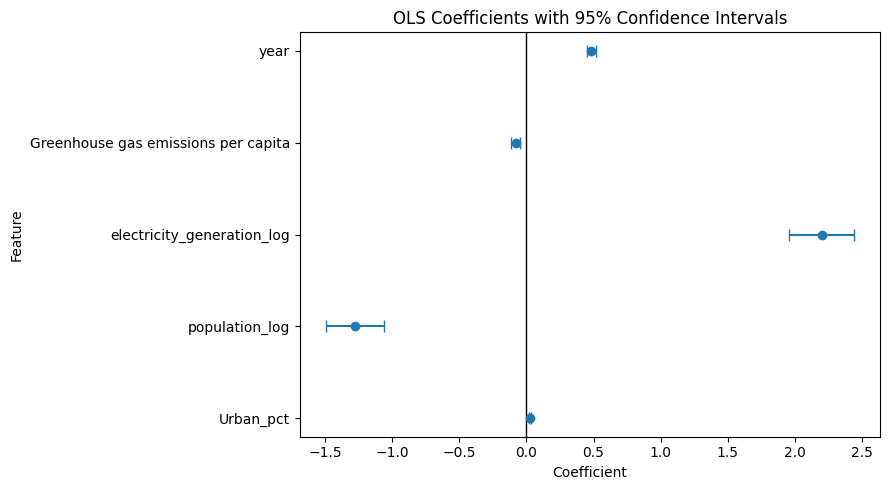

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_table = ols_table[ols_table["feature"] != "const"].copy()

plt.figure(figsize=(9, 5))

plt.errorbar(
    plot_table["coef"],
    plot_table["feature"],
    xerr=[
        plot_table["coef"] - plot_table["ci_low"],
        plot_table["ci_high"] - plot_table["coef"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(0, color="black", linewidth=1)
plt.title("OLS Coefficients with 95% Confidence Intervals")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpretation:** The coefficient plot shows both the direction and uncertainty of each predictor. Confidence intervals that do not cross zero indicate statistically significant associations. Urbanization, electricity generation, and year trend are on the positive side, while emissions per capita and population are negative after controls. The plot is useful for explaining association, not causation.


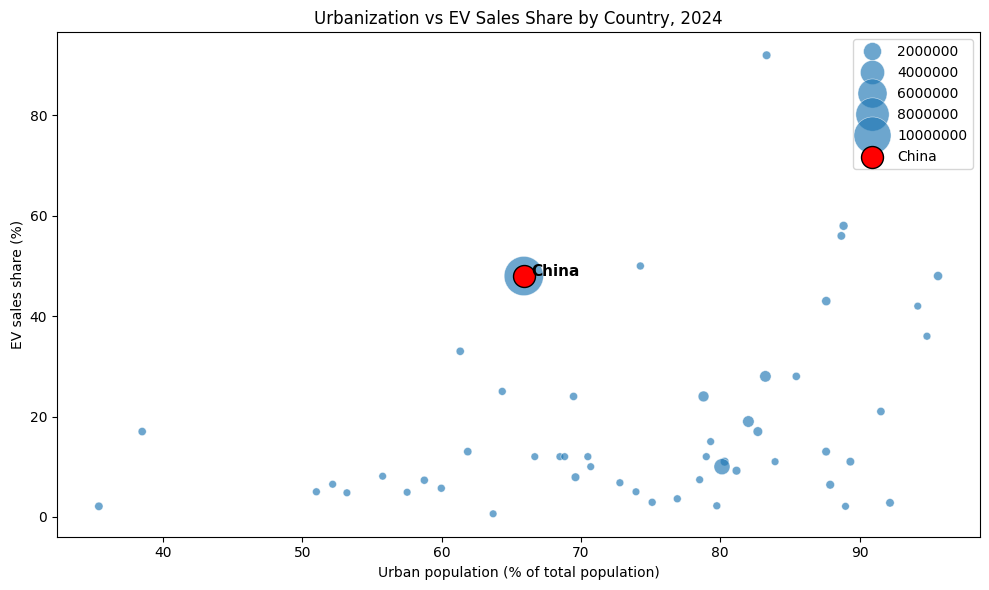

In [ ]:
scatter_df = country_df[
    (country_df["year"] == 2024)
].dropna(subset=["Urban_pct", "ev_sales_share", "ev_sales"])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_df,
    x="Urban_pct",
    y="ev_sales_share",
    size="ev_sales",
    sizes=(30, 800),
    alpha=0.65,
    legend=True
)

china_2024 = scatter_df[scatter_df["region_country"] == "China"]

plt.scatter(
    china_2024["Urban_pct"],
    china_2024["ev_sales_share"],
    color="red",
    s=250,
    edgecolor="black",
    label="China"
)

for _, row in china_2024.iterrows():
    plt.text(
        row["Urban_pct"] + 0.5,
        row["ev_sales_share"],
        "China",
        fontsize=11,
        weight="bold"
    )

plt.title("Urbanization vs EV Sales Share by Country, 2024")
plt.xlabel("Urban population (% of total population)")
plt.ylabel("EV sales share (%)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The 2024 scatter plot shows the cross-country relationship between urbanization and EV sales share. The relationship is positive but not deterministic: countries with similar urbanization levels can have very different EV adoption outcomes. China stands out because its EV sales volume is very large even though its urbanization rate is not the highest, suggesting that scale, policy, and market structure matter beyond urbanization alone.


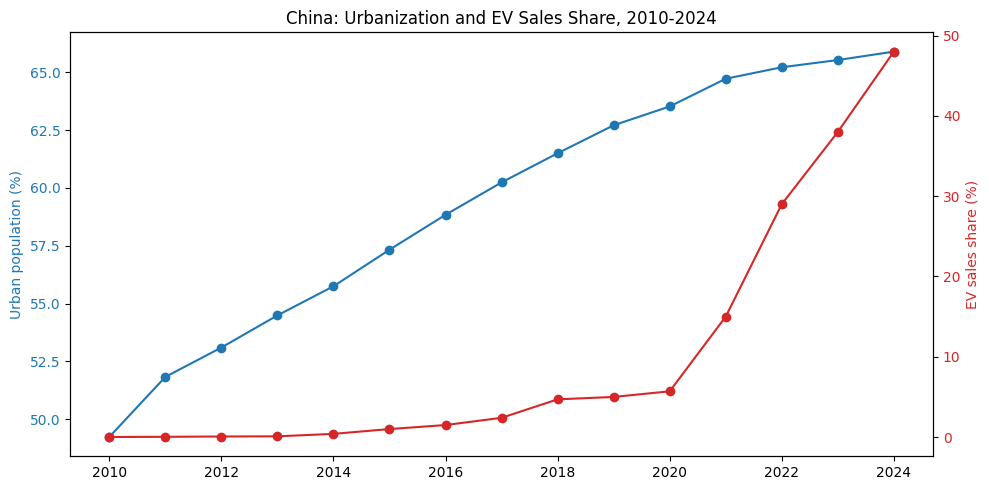

In [ ]:
china = country_df[country_df["region_country"] == "China"].sort_values("year")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    china["year"],
    china["Urban_pct"],
    marker="o",
    color="tab:blue",
    label="Urban_pct"
)

ax1.set_ylabel("Urban population (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

ax2.plot(
    china["year"],
    china["ev_sales_share"],
    marker="o",
    color="tab:red",
    label="EV sales share"
)

ax2.set_ylabel("EV sales share (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("China: Urbanization and EV Sales Share, 2010-2024")
fig.tight_layout()
plt.show()

**Interpretation:** China shows a clear divergence between gradual urbanization growth and rapid EV adoption after 2020. Urbanization rises steadily, while EV sales share accelerates sharply from near zero to a much higher level. This visual pattern supports the later Granger result: the two variables co-move over time, but urbanization does not clearly lead EV adoption in a statistically detectable way.


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd

def run_granger_log_multi_lag(
    country,
    x_col="Urban_pct",
    y_col="ev_sales_log",
    maxlag=4,
    min_obs_buffer=5
):
    temp = (
        country_df[country_df["region_country"] == country]
        .sort_values("year")[["year", y_col, x_col]]
        .dropna()
    )

    print(f"{country}: {temp.shape[0]} observations")
    print(temp)

    # With short annual series, too many lags will overfit / fail
    max_allowed_lag = max(1, temp.shape[0] - min_obs_buffer)

    if maxlag > max_allowed_lag:
        print(
            f"Requested maxlag={maxlag}, but only {temp.shape[0]} observations. "
            f"Using maxlag={max_allowed_lag} instead."
        )
        maxlag = max_allowed_lag

    if temp.shape[0] < maxlag + min_obs_buffer:
        print("Not enough observations for this maxlag.")
        return None, None

    result = grangercausalitytests(
        temp[[y_col, x_col]],
        maxlag=maxlag,
        verbose=True
    )

    summary = []

    for lag, lag_result in result.items():
        tests = lag_result[0]

        summary.append({
            "country": country,
            "x_predictor": x_col,
            "y_target": y_col,
            "lag": lag,
            "ssr_F_stat": tests["ssr_ftest"][0],
            "ssr_F_p_value": tests["ssr_ftest"][1],
            "chi2_stat": tests["ssr_chi2test"][0],
            "chi2_p_value": tests["ssr_chi2test"][1],
            "significant_0.05": tests["ssr_ftest"][1] < 0.05
        })

    summary = pd.DataFrame(summary)

    return result, summary


granger_china, granger_summary = run_granger_log_multi_lag(
    country="China",
    x_col="Urban_pct",
    y_col="ev_sales_log",
    maxlag=4
)

granger_summary

China: 15 observations
     year  ev_sales_log  Urban_pct
94   2010      7.273093  49.234027
95   2011      8.541105  51.830029
96   2012      9.196343  53.100311
97   2013      9.663389  54.490002
98   2014     11.198228  55.750256
99   2015     12.259618  57.329784
100  2016     12.733758  58.839924
101  2017     13.270785  60.240269
102  2018     13.901689  61.500198
103  2019     13.873780  62.709915
104  2020     13.946540  63.523423
105  2021     14.994166  64.721077
106  2022     15.590463  65.217636
107  2023     15.907375  65.530145
108  2024     16.240313  65.894698

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1
ssr based chi2 test:   chi2=1.2990  , p=0.2544  , df=1
likelihood ratio test: chi2=1.2422  , p=0.2650  , df=1
parameter F test:         F=1.0206  , p=0.3341  , df_denom=11, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2083  , p=0.3479  , df_denom=8, df_num=2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


,country,x_predictor,y_target,lag,ssr_F_stat,ssr_F_p_value,chi2_stat,chi2_p_value,significant_0.05
0,China,Urban_pct,ev_sales_log,1,1.020637,0.334075,1.298992,0.254397,False
1,China,Urban_pct,ev_sales_log,2,1.208266,0.347910,3.926865,0.140376,False
2,China,Urban_pct,ev_sales_log,3,1.227250,0.391382,8.836199,0.031550,False
3,China,Urban_pct,ev_sales_log,4,1.210492,0.499180,26.630813,0.000024,False


**Interpretation:** The Granger test checks whether past urbanization values help predict future EV sales log in China. Using the SSR F-test as the main small-sample criterion, lags 1 through 4 are all not statistically significant because their p-values are above 0.05. Some chi-square p-values become significant at longer lags, but those are not reliable here because China only has 15 annual observations and higher-lag tests leave very few degrees of freedom. Overall, the test finds no robust evidence that past urbanization predicts future EV sales in China.


In [ ]:
granger_summary = []

for lag, result in granger_china.items():
    tests = result[0]

    granger_summary.append({
        "lag": lag,
        "ssr_F_stat": tests["ssr_ftest"][0],
        "ssr_F_p_value": tests["ssr_ftest"][1],
        "chi2_stat": tests["ssr_chi2test"][0],
        "chi2_p_value": tests["ssr_chi2test"][1]
    })

granger_summary = pd.DataFrame(granger_summary)

granger_summary

,lag,ssr_F_stat,ssr_F_p_value,chi2_stat,chi2_p_value
0,1,1.020637,0.334075,1.298992,0.254397
1,2,1.208266,0.347910,3.926865,0.140376
2,3,1.227250,0.391382,8.836199,0.031550
3,4,1.210492,0.499180,26.630813,0.000024


**Interpretation:** This summary confirms that `Urban_pct` does not Granger-cause `ev_sales_log` for China under the SSR F-test at lags 1-4. We therefore fail to reject the null hypothesis of no Granger causality. This does not contradict the OLS regression result: OLS shows a cross-sectional association, while Granger tests whether past urbanization improves time-series prediction. The evidence supports positive association, not causation.


In [ ]:
ols_table.to_csv("ols_final_results.csv", index=False)
granger_summary.to_csv("granger_china_results.csv", index=False)
scatter_df.to_csv("scatter_urban_ev_share_2024.csv", index=False)
china.to_csv("china_trend_data.csv", index=False)

print("Exported:")
print("- ols_final_results.csv")
print("- granger_china_results.csv")
print("- scatter_urban_ev_share_2024.csv")
print("- china_trend_data.csv")

Exported:
- ols_final_results.csv
- granger_china_results.csv
- scatter_urban_ev_share_2024.csv
- china_trend_data.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Predict expected EV sales from OLS model
X_gap = sm.add_constant(model_df[final_features], has_constant="add")

model_df["expected_ev_sales_log"] = ols_final.predict(X_gap)
model_df["adoption_gap_log"] = model_df["ev_sales_log"] - model_df["expected_ev_sales_log"]

# Convert log predictions back to sales scale for interpretability
model_df["expected_ev_sales"] = np.expm1(model_df["expected_ev_sales_log"])
model_df["adoption_gap_sales"] = model_df["ev_sales"] - model_df["expected_ev_sales"]

# Keep latest available year for country comparison
adoption_gap_2024 = (
    model_df[model_df["year"] == 2024]
    .copy()
    .sort_values("adoption_gap_log", ascending=False)
)

adoption_gap_2024[
    [
        "region_country",
        "year",
        "ev_sales",
        "expected_ev_sales",
        "adoption_gap_sales",
        "adoption_gap_log",
        "ev_sales_share",
        "Urban_pct"
    ]
].head(10)

,region_country,year,ev_sales,expected_ev_sales,adoption_gap_sales,adoption_gap_log,ev_sales_share,Urban_pct
377,Luxembourg,2024,16800.0,1.106309e+03,1.569369e+04,2.719506,36.0,94.843870
643,United Kingdom,2024,550000.0,1.202085e+05,4.297915e+05,1.520684,28.0,83.242954
479,Portugal,2024,70000.0,1.572224e+04,5.427776e+04,1.493370,33.0,61.328191
108,China,2024,11300000.0,2.868460e+06,8.431540e+06,1.371027,48.0,65.894698
40,Belgium,2024,197000.0,5.468185e+04,1.423181e+05,1.281659,43.0,87.612656
168,Denmark,2024,96100.0,2.841879e+04,6.768121e+04,1.218314,56.0,88.696055
132,Costa Rica,2024,11022.0,3.530610e+03,7.491390e+03,1.138230,15.0,79.310767
292,Ireland,2024,30000.0,9.976985e+03,2.002302e+04,1.100850,25.0,64.347038
645,Uzbekistan,2024,22600.0,7.536142e+03,1.506386e+04,1.098151,5.0,50.998669
282,Indonesia,2024,49150.0,1.704630e+04,3.210370e+04,1.058906,7.3,58.750964


**Interpretation:** Adoption Gap compares actual EV sales with OLS-expected EV sales based on socioeconomic fundamentals. A positive gap means a country sells more EVs than expected from urbanization, population, electricity generation, emissions, and year trend. The top countries here overperform their fundamentals, suggesting that factors outside the current dataset, such as policy support, incentives, charging rollout, or market strategy, may help explain their EV adoption.


In [ ]:
top_overperformers = adoption_gap_2024.head(10).copy()
top_underperformers = adoption_gap_2024.tail(10).copy()

gap_summary = pd.concat([
    top_overperformers.assign(group="Overperformers"),
    top_underperformers.assign(group="Underperformers")
])

gap_summary = gap_summary[
    [
        "region_country",
        "group",
        "ev_sales",
        "expected_ev_sales",
        "adoption_gap_sales",
        "adoption_gap_log",
        "ev_sales_share",
        "Urban_pct"
    ]
].sort_values("adoption_gap_log", ascending=False)

gap_summary

,region_country,group,ev_sales,expected_ev_sales,adoption_gap_sales,adoption_gap_log,ev_sales_share,Urban_pct
377,Luxembourg,Overperformers,16800.0,1.106309e+03,1.569369e+04,2.719506,36.00,94.843870
643,United Kingdom,Overperformers,550000.0,1.202085e+05,4.297915e+05,1.520684,28.00,83.242954
479,Portugal,Overperformers,70000.0,1.572224e+04,5.427776e+04,1.493370,33.00,61.328191
108,China,Overperformers,11300000.0,2.868460e+06,8.431540e+06,1.371027,48.00,65.894698
40,Belgium,Overperformers,197000.0,5.468185e+04,1.423181e+05,1.281659,43.00,87.612656
168,Denmark,Overperformers,96100.0,2.841879e+04,6.768121e+04,1.218314,56.00,88.696055
132,Costa Rica,Overperformers,11022.0,3.530610e+03,7.491390e+03,1.138230,15.00,79.310767
292,Ireland,Overperformers,30000.0,9.976985e+03,2.002302e+04,1.100850,25.00,64.347038
645,Uzbekistan,Overperformers,22600.0,7.536142e+03,1.506386e+04,1.098151,5.00,50.998669
282,Indonesia,Overperformers,49150.0,1.704630e+04,3.210370e+04,1.058906,7.30,58.750964


**Interpretation:** This table separates the strongest overperformers and underperformers in 2024. Overperformers have actual EV sales above OLS-expected levels, while underperformers have actual sales below expected levels. The gap should not be interpreted as model error only; it is also a useful diagnostic for identifying markets where policy, infrastructure, affordability, or consumer behavior may be shaping EV adoption beyond the measured fundamentals.


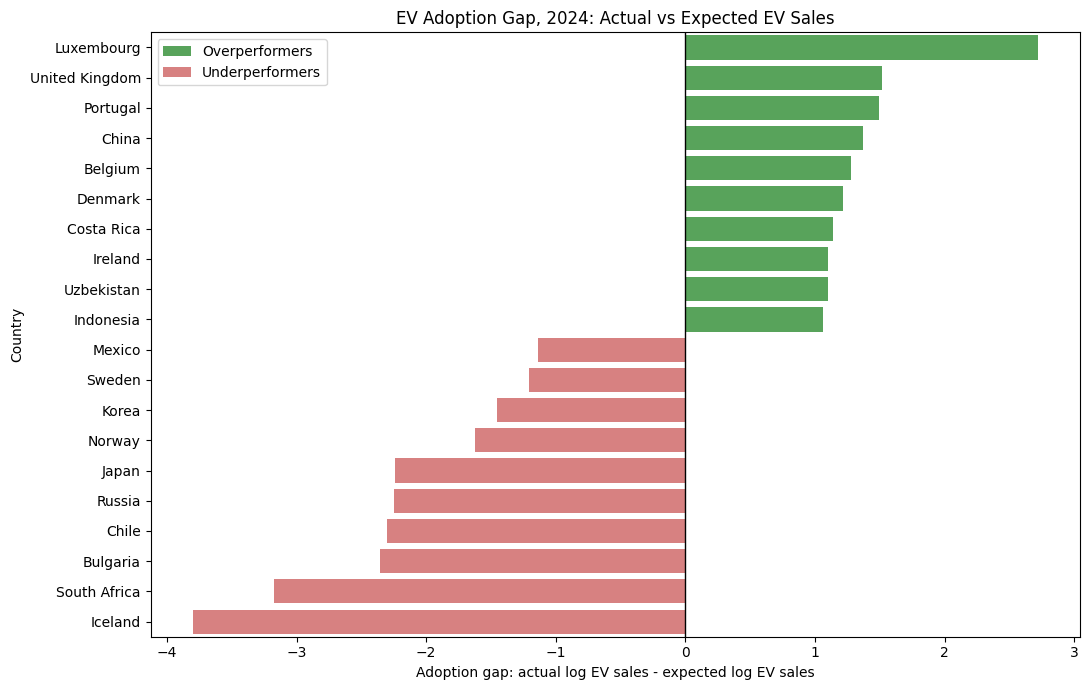

In [ ]:
plot_gap = gap_summary.copy()

plt.figure(figsize=(11, 7))

sns.barplot(
    data=plot_gap,
    x="adoption_gap_log",
    y="region_country",
    hue="group",
    dodge=False,
    palette={
        "Overperformers": "#4CAF50",
        "Underperformers": "#E57373"
    }
)

plt.axvline(0, color="black", linewidth=1)
plt.title("EV Adoption Gap, 2024: Actual vs Expected EV Sales")
plt.xlabel("Adoption gap: actual log EV sales - expected log EV sales")
plt.ylabel("Country")
plt.legend(title="")
plt.tight_layout()
plt.show()

**Interpretation:** The bar chart visualizes the EV Adoption Gap directly. Countries to the right of zero overperform relative to expected adoption, while countries to the left underperform. This chart is useful for the dashboard because it turns the regression result into a market story: EV adoption is not fully explained by socioeconomic fundamentals, and the remaining gap points to possible policy and ecosystem effects.


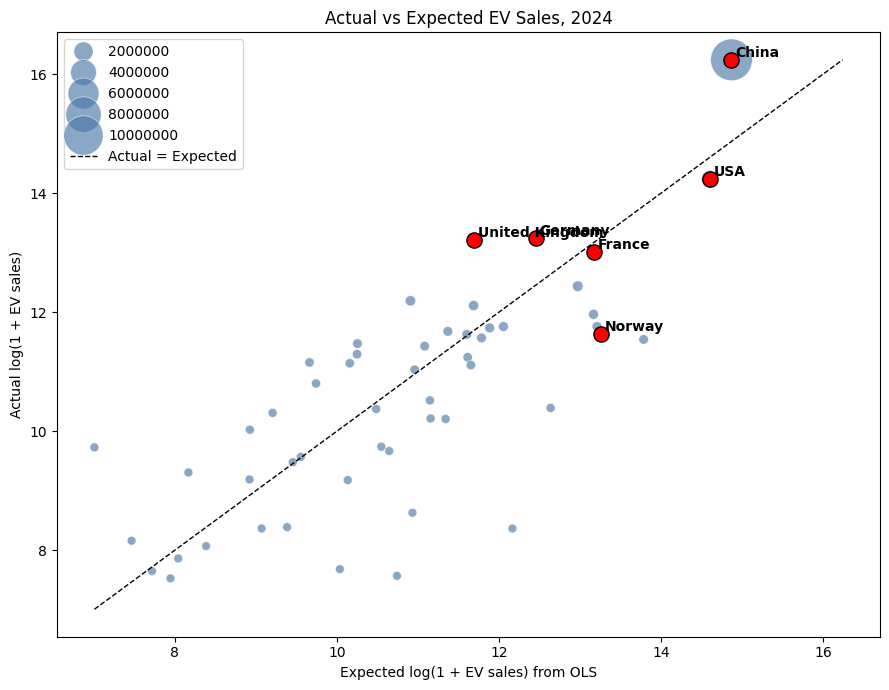

In [ ]:
highlight_countries = ["China", "Norway", "USA", "Germany", "France", "United Kingdom"]

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=adoption_gap_2024,
    x="expected_ev_sales_log",
    y="ev_sales_log",
    size="ev_sales",
    sizes=(40, 900),
    alpha=0.65,
    color="#4C78A8"
)

# 45-degree reference line
min_val = min(adoption_gap_2024["expected_ev_sales_log"].min(), adoption_gap_2024["ev_sales_log"].min())
max_val = max(adoption_gap_2024["expected_ev_sales_log"].max(), adoption_gap_2024["ev_sales_log"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    linewidth=1,
    label="Actual = Expected"
)

for country in highlight_countries:
    row = adoption_gap_2024[adoption_gap_2024["region_country"] == country]
    if not row.empty:
        x = row["expected_ev_sales_log"].iloc[0]
        y = row["ev_sales_log"].iloc[0]

        plt.scatter(x, y, color="red", s=120, edgecolor="black")
        plt.text(x + 0.05, y + 0.05, country, fontsize=10, weight="bold")

plt.title("Actual vs Expected EV Sales, 2024")
plt.xlabel("Expected log(1 + EV sales) from OLS")
plt.ylabel("Actual log(1 + EV sales)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The actual-vs-expected scatter shows whether each country is above or below the OLS expectation line. Points above the diagonal sell more EVs than expected, while points below sell fewer than expected. Highlighted countries help compare different adoption patterns: China overperforms by scale, while some high-share but smaller markets can appear under expected sales volume because the model target is total EV sales rather than sales share.


In [ ]:
adoption_gap_interpretation = adoption_gap_2024[
    [
        "region_country",
        "ev_sales",
        "expected_ev_sales",
        "adoption_gap_sales",
        "adoption_gap_log",
        "ev_sales_share",
        "Urban_pct",
        "population",
        "electricity_generation",
        "Greenhouse gas emissions per capita"
    ]
].copy()

adoption_gap_interpretation["gap_label"] = np.where(
    adoption_gap_interpretation["adoption_gap_log"] > 0,
    "Overperforms expected adoption",
    "Underperforms expected adoption"
)

adoption_gap_interpretation.sort_values(
    "adoption_gap_log",
    ascending=False
).head(15)

,region_country,ev_sales,expected_ev_sales,adoption_gap_sales,adoption_gap_log,ev_sales_share,Urban_pct,population,electricity_generation,Greenhouse gas emissions per capita,gap_label
377,Luxembourg,16800.0,1.106309e+03,1.569369e+04,2.719506,36.0,94.843870,673042,1.510000,11.798287,Overperforms expected adoption
643,United Kingdom,550000.0,1.202085e+05,4.297915e+05,1.520684,28.0,83.242954,69138185,284.160004,5.644861,Overperforms expected adoption
479,Portugal,70000.0,1.572224e+04,5.427776e+04,1.493370,33.0,61.328191,10425291,47.270000,5.197852,Overperforms expected adoption
108,China,11300000.0,2.868460e+06,8.431540e+06,1.371027,48.0,65.894698,1419321284,10086.879880,9.939262,Overperforms expected adoption
40,Belgium,197000.0,5.468185e+04,1.423181e+05,1.281659,43.0,87.612656,11738761,76.010002,9.195861,Overperforms expected adoption
168,Denmark,96100.0,2.841879e+04,6.768121e+04,1.218314,56.0,88.696055,5977417,35.060001,7.685419,Overperforms expected adoption
132,Costa Rica,11022.0,3.530610e+03,7.491390e+03,1.138230,15.0,79.310767,5129909,11.000000,2.920522,Overperforms expected adoption
292,Ireland,30000.0,9.976985e+03,2.002302e+04,1.100850,25.0,64.347038,5255016,31.080000,11.456779,Overperforms expected adoption
645,Uzbekistan,22600.0,7.536142e+03,1.506386e+04,1.098151,5.0,50.998669,36361859,81.500000,5.725033,Overperforms expected adoption
282,Indonesia,49150.0,1.704630e+04,3.210370e+04,1.058906,7.3,58.750964,283487933,371.540008,6.711167,Overperforms expected adoption


**Interpretation:** This output adds an interpretable label to each country: overperforming or underperforming expected adoption. It is designed for dashboard tooltips, country detail panels, or insight cards. The label should be read as an explanatory diagnostic, not as a causal proof or forecast.


In [ ]:
adoption_gap_2024.to_csv("adoption_gap_2024.csv", index=False)
gap_summary.to_csv("adoption_gap_top_bottom_2024.csv", index=False)
adoption_gap_interpretation.to_csv("adoption_gap_interpretation_2024.csv", index=False)

print("Exported:")
print("- adoption_gap_2024.csv")
print("- adoption_gap_top_bottom_2024.csv")
print("- adoption_gap_interpretation_2024.csv")

Exported:
- adoption_gap_2024.csv
- adoption_gap_top_bottom_2024.csv
- adoption_gap_interpretation_2024.csv
